# **Denoising de espectros LIBS usando Undecimated Wavelet Transform (UWT)**


Este método de eliminación de ruido se basa en la **Undecimated Wavelet Transform (UWT)**, una técnica que descompone el espectro en distintos niveles de detalle sin perder resolución (no hay decimación). Los **wavelets** son funciones matemáticas que permiten analizar una señal en diferentes escalas o "resoluciones", separando detalles finos (como el ruido) de estructuras más amplias (como las líneas espectrales o el continuo).

En esta técnica, descomponemos el espectro en varios niveles utilizando un **wavelet suavizado** (como `sym8` o `bior3.3`), y nos enfocamos en los **coeficientes de detalle** (`cD`) que contienen las variaciones rápidas de la señal. Como el ruido suele manifestarse como fluctuaciones pequeñas y rápidas, esperamos que esté mayormente contenido en esos coeficientes.

Luego aplicamos un **"sigma clipping"**: estimamos la desviación estándar del ruido `σ`, y anulamos todos los coeficientes cuya magnitud es menor que `3σ`. Esta operación filtra el ruido sin afectar las estructuras reales del espectro. Finalmente, reconstruimos el espectro original a partir de los coeficientes filtrados. El resultado es un espectro más limpio, que conserva las líneas relevantes y elimina el fondo ruidoso sin necesidad de conocer previamente la forma del ruido.

Trabajaremos con dos enfoques distintos:
- **Método 1: Sigma Clipping basado en la Mediana (MAD)**.
- **Método 2: Sigma Clipping iterativo tipo SuperCam**.

## Código Explicado

### 1. Importación de librerías y carga de datos

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import pywt

#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Scope Corrected for Dark'] = pd.to_numeric(df['Scope Corrected for Dark'], errors='coerce')
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None

# Función para hacer padding hasta múltiplo de 2^level
def pad_to_multiple(x, base):
    remainder = len(x) % base
    if remainder == 0:
        return x, 0
    pad_size = base - remainder
    x_padded = np.pad(x, (0, pad_size), mode='edge')  # relleno por repetición del borde
    return x_padded, pad_size

In [2]:
# Ruta relativa desde Pre_Processing a los espectros
ruta_espectros = os.path.join('..', 'Spectra', '2.E2E_olivine')

UV1 = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324767SP.txt')
UV2 = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324768SP.txt')
VIS = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324769SP.txt')
NIR = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324770SP.txt')

datos_UV1 = leer_archivo_txt(UV1)
datos_UV2 = leer_archivo_txt(UV2)
datos_VIS = leer_archivo_txt(VIS)
datos_NIR = leer_archivo_txt(NIR)

espectro_UV1 = datos_UV1['Scope Corrected for Dark'].values
wavelength = datos_UV1['Wave'].values

#Le quitamos los extremos que no aportan nada
espectro_UV1 = espectro_UV1[16:-16]
wavelength = wavelength[16:-16]
#plt.plot(wavelength, espectro_UV1)

### 2. Definición del Wavelet

Primero intentamos crear el filtro que usa SuperCam, una función de escalado B3-spline, y unos filtros concretos, pero sin mucho éxito. Finalmente usaremos `pywt.Wavelet('bior3.3')` como aproximación al filtro suavizado utilizado en SuperCam.

In [3]:
#Simulamos el Undecimated Wavelet Transform (UWT)
#usamos la función pywt.swt(signal, wavelet, level) que realiza la transformada wavelet estacionaria
#signal: nuestro espectro
#wavelet: para aproximarse a B_3-spline de SuperCam crearemos nuestro propio wavelet
#level: número de niveles de descomposición


#Creamos nuestro wavelet siguiendo los filtros de super cam
#Low pass filter h(z) = 1/16(z^-2 + 4z^-1 + 6 + 4z + z^2)
h = [0,0,0,1,4,6,4,1,0,0]
h = [x/16 for x in h]

#High pass filter g(z) = 1/256(-z^-4 -8z^-3 - 28z^-2 -56z^-1 +186 -56z - 28z^2 - 8z^3 - z^4)
g = [0,-1,-8,-28,-56,186,-56,-28,-8,-1]
g = [x/256 for x in g]

#Armar el banco de filtros en el orden requerido
filter_bank = [h,g,h,g] #UWT usa mismos filtros para análisis y síntesis

#Creamos el wavelet personalizado
supercam_wavelet = pywt.Wavelet(name="supercam", filter_bank=filter_bank)

### 3. Verificación de la reconstrucción UWT + ISWT

Probamos que el espectro puede reconstruirse correctamente tras una descomposición y reconstrucción sin modificación de coeficientes. Probamos diferentes wavelets mediante reconstrucción directa del espectro.

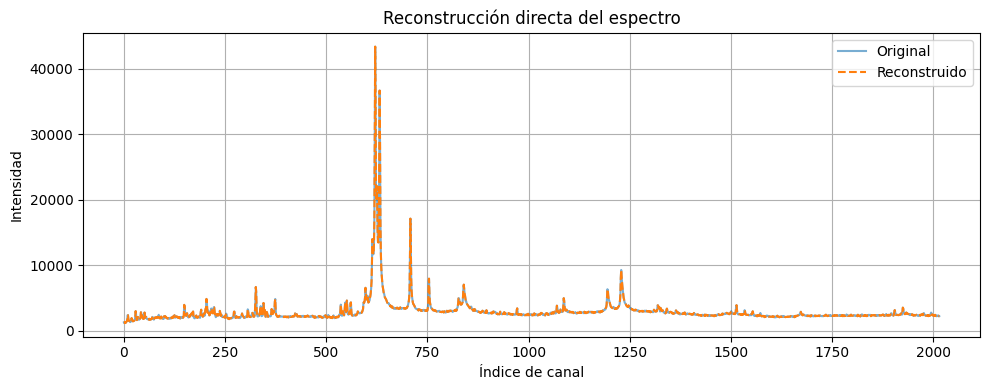

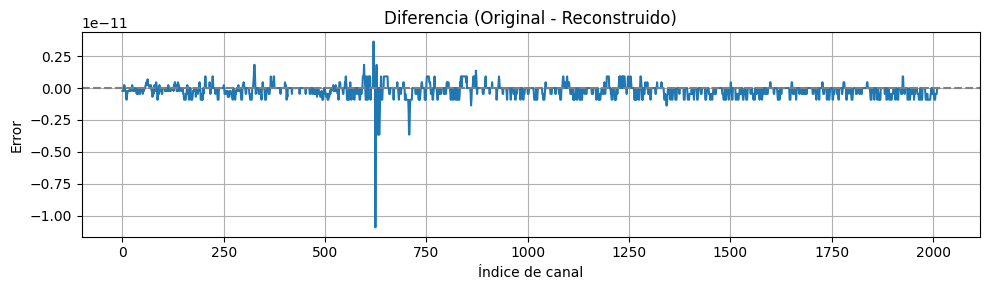

Error absoluto máximo: 1.0913936421275139e-11


In [10]:
# Parámetros del wavelet y número de niveles
wavelet = pywt.Wavelet('bior3.3')  
#wavelet = supercam_wavelet 
#wavelet = custom_wavelet


level = 3  

# Preparamos el espectro
espectro_padded, pad_size = pad_to_multiple(espectro_UV1, 2**level)

# Transformada SWT
coeffs = pywt.swt(espectro_padded, wavelet, level=level)

# Reconstrucción directa
recon_padded = pywt.iswt(coeffs, wavelet)
recon = recon_padded[:len(espectro_UV1)]  # quitamos el padding

# Comparación visual
plt.figure(figsize=(10, 4))
plt.plot(espectro_UV1, label='Original', alpha=0.6)
plt.plot(recon, label='Reconstruido', linestyle='--')
plt.title("Reconstrucción directa del espectro")
plt.xlabel("Índice de canal")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Error punto a punto
error = espectro_UV1 - recon
plt.figure(figsize=(10, 3))
plt.plot(error, label='Error')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Diferencia (Original - Reconstruido)")
plt.xlabel("Índice de canal")
plt.ylabel("Error")
plt.grid(True)
plt.tight_layout()
plt.show()

# Error máximo
print("Error absoluto máximo:", np.max(np.abs(error)))

### 4. Descomposición del espectro con UWT
Descomponemos el espectro en sus diferentes niveles y los representamos, para ver la relevancia de cada nivel.

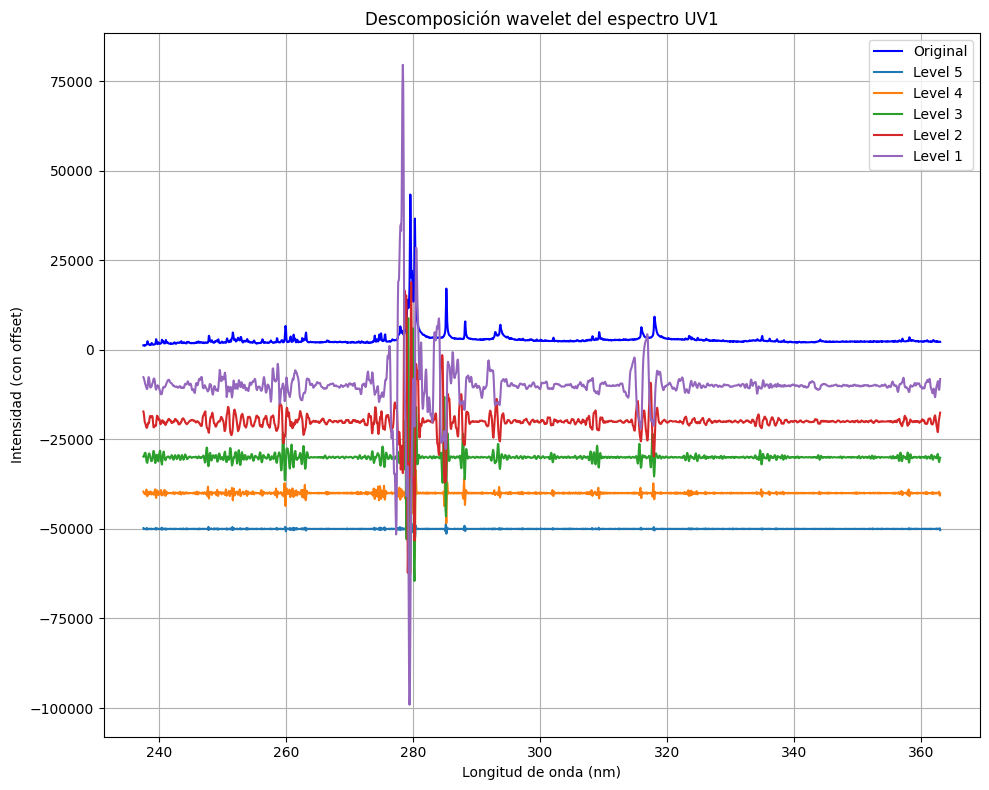

In [11]:
wavelet = pywt.Wavelet('bior3.3')
#wavelet = supercam_wavelet

# Reaplicar el nivel correcto
level = 5
coeffs = pywt.swt(espectro_UV1, wavelet, level=level)

# Gráfico tipo SuperCam con offset vertical por escala
plt.figure(figsize=(10, 8))

# Espectro original
plt.plot(wavelength, espectro_UV1, label="Original", color='blue')

# Dibujamos cada escala con desplazamiento vertical
offset = 10000  # para separación entre escalas
for i, (cA, cD) in enumerate(reversed(coeffs)):
    level_num = level - i
    plt.plot(wavelength, cD - offset * level_num, label=f"Level {level_num}")

plt.title("Descomposición wavelet del espectro UV1")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Intensidad (con offset)")
plt.legend()
plt.grid(True)
plt.tight_layout()


### 5. Denoising con Sigma Clipping basado en Mediana (MAD)

Este método estima la desviación estándar del ruido usando la fórmula:

\[
\sigma \approx \frac{\text{mediana}(|cD|)}{0.6745}
\]

Todos los coeficientes de detalle por debajo de 3σ se anulan.Quitamos el ruido y reconstruimos con sigma clipping Median Absolute Deviation scaled to σ

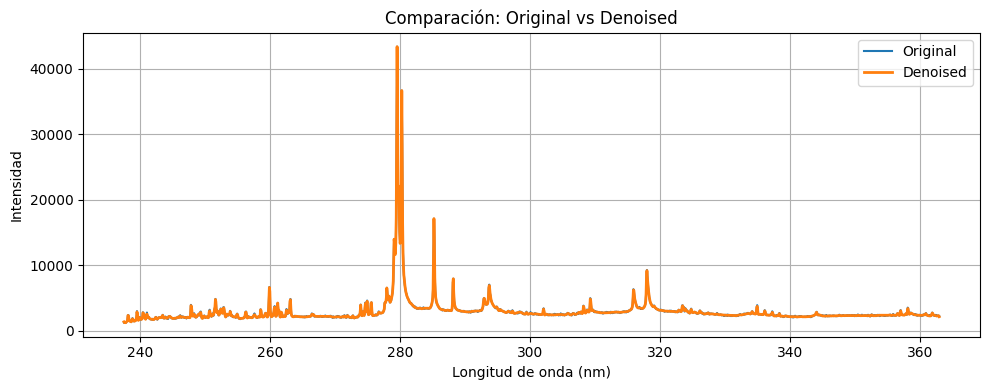

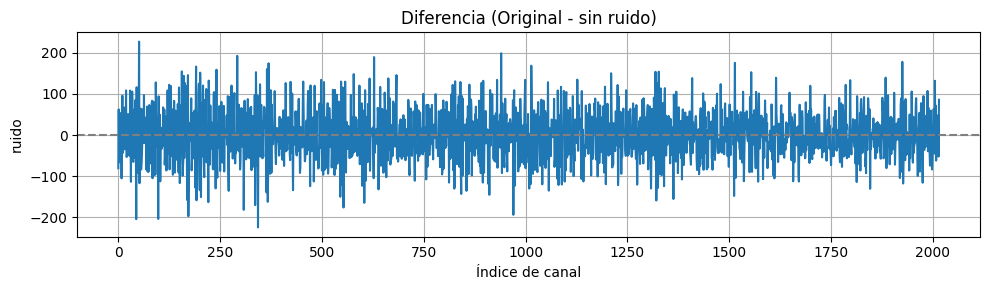

In [12]:
wavelet = pywt.Wavelet('bior3.3')

# Reaplicar el nivel correcto
level = 5
coeffs = pywt.swt(espectro_UV1, wavelet, level=level)

#MAD → Median Absolute Deviation scaled to σ
sigma = np.median(np.abs(coeffs[-1][1])) / 0.6745  # Estimación robusta de la desviación estándar
threshold = 5 * sigma

# Aplicamos el umbral a los coeficientes de detalle
filtered_coeffs = [(cA, pywt.threshold(cD, threshold, mode='hard',substitute=0)) for cA, cD in coeffs]

#Recosntuir el espectro
denoised_spectrum_UV1 = pywt.iswt(filtered_coeffs, wavelet)

# Comparamos resultados
plt.figure(figsize=(10, 4))
plt.plot(wavelength, espectro_UV1, label="Original")
plt.plot(wavelength, denoised_spectrum_UV1, label="Denoised", linewidth=2)
plt.title("Comparación: Original vs Denoised")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Ruido punto a punto
error = espectro_UV1 - denoised_spectrum_UV1
plt.figure(figsize=(10, 3))
plt.plot(error, label='Ruido quitado')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Diferencia (Original - sin ruido)")
plt.xlabel("Índice de canal")
plt.ylabel("ruido")
plt.grid(True)
plt.tight_layout()
plt.show()

### 6. Denoising iterativo tipo SuperCam

Este método repite el cálculo de σ varias veces, descartando valores grandes (potenciales líneas espectrales) para refinar la estimación del ruido. Finalmente, se anulan los coeficientes de detalle por debajo de 3σ.

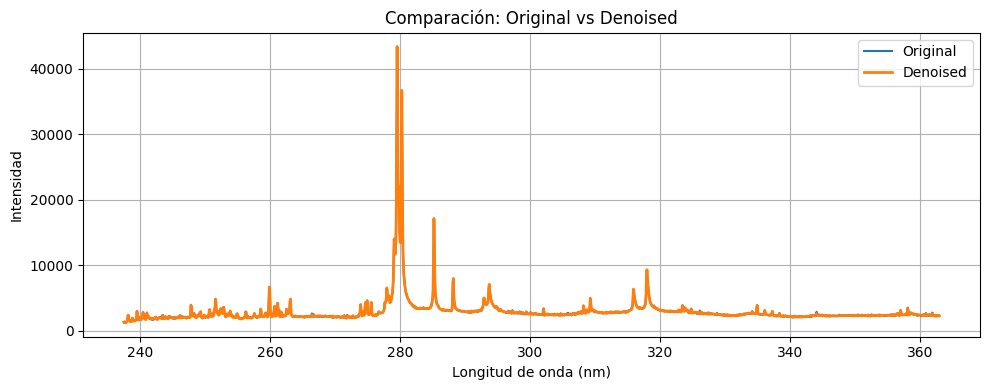

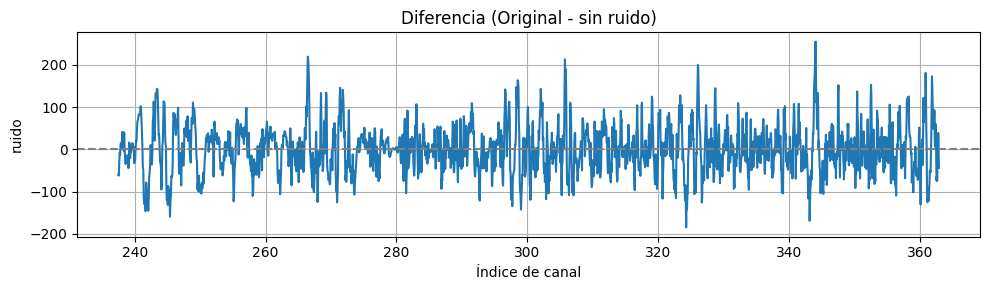

In [ ]:
#Definimos la función para el sigma clipping
#CREO que estamos perdiendo de esta forma información relevante, no pretendo usar este método
def sigma_clipping_supercam(coeffs, n_iter=5, threshold_sigma=3):
    """
    Aplica sigma clipping iterativo al estilo SuperCam.
    
    Args:
        coeffs: lista de tuplas (cA, cD) de la SWT.
        n_iter: número de iteraciones para refinar la estimación del sigma.
        threshold_sigma: umbral de corte en múltiplos de sigma.

    Returns:
        coeffs filtrados con cD modificados.
    """
    filtered_coeffs = []

    for i, (cA, cD) in enumerate(coeffs):
        cD_abs = np.abs(cD)

        # Sigma clipping iterativo sobre los coeficientes bajos
        mask = np.ones_like(cD_abs, dtype=bool)

        for _ in range(n_iter):
            sigma = np.std(cD_abs[mask])
            mask = cD_abs < (threshold_sigma * sigma)

        # Último sigma para aplicar el umbral
        sigma_final = np.std(cD_abs[mask])
        threshold = threshold_sigma * sigma_final

        # Aplicar el umbral final
        cD_filtered = np.where(cD_abs < threshold, 0, cD)

        filtered_coeffs.append((cA, cD_filtered))

    return filtered_coeffs


#Lo aplicamos a los coeficientes
wavelet = pywt.Wavelet('bior3.3')

# Reaplicar el nivel correcto
level = 5
coeffs = pywt.swt(espectro_UV1, wavelet, level=level)

# Aplicamos el umbral a los coeficientes de detalle
filtered_coeffs = sigma_clipping_supercam(coeffs, n_iter=5, threshold_sigma=3)

#Recosntuir el espectro
denoised_spectrum_UV1 = pywt.iswt(filtered_coeffs, wavelet)

# Comparamos resultados
plt.figure(figsize=(10, 4))
plt.plot(wavelength, espectro_UV1, label="Original")
plt.plot(wavelength, denoised_spectrum_UV1, label="Denoised", linewidth=2)
plt.title("Comparación: Original vs Denoised")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Ruido punto a punto
error = espectro_UV1 - denoised_spectrum_UV1
plt.figure(figsize=(10, 3))
plt.plot(wavelength, error, label='Ruido quitado')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Diferencia (Original - sin ruido)")
plt.xlabel("Índice de canal")
plt.ylabel("ruido")
plt.grid(True)
plt.tight_layout()
plt.show()

## Función completa para quitar el ruido

In [8]:
import numpy as np
import pywt

def denoise_spectrum_uwt(spectrum, wavelet_name='bior3.3', level=None, threshold_sigma=3):
    """
    Aplica reducción de ruido (denoising) a un espectro usando UWT y sigma clipping.

    Parámetros:
    ------------
    spectrum : array_like
        Espectro 1D original (array de intensidades).
    wavelet_name : str, opcional
        Nombre del wavelet a utilizar. Por defecto 'bior3.3'.
    level : int, opcional
        Nivel de descomposición wavelet. Si no se especifica, se calcula automáticamente.
    threshold_sigma : float, opcional
        Umbral de sigma para eliminar coeficientes de detalle (por defecto 3σ).

    Devuelve:
    ---------
    spectrum_denoised : np.ndarray
        Espectro reconstruido con el ruido eliminado.
    """

    # Asegurar entrada como array NumPy
    spectrum = np.asarray(spectrum)
    original_len = len(spectrum)

    # Obtener nivel máximo si no se especifica
    if level is None:
        level = pywt.swt_max_level(original_len)

    # Hacer padding si es necesario
    def pad_to_multiple(x, base):
        remainder = len(x) % base
        if remainder == 0:
            return x, 0
        pad_size = base - remainder
        x_padded = np.pad(x, (0, pad_size), mode='edge')
        return x_padded, pad_size

    spectrum_padded, pad_size = pad_to_multiple(spectrum, 2 ** level)

    # Descomposición SWT
    coeffs = pywt.swt(spectrum_padded, wavelet_name, level=level)

    # Aplicar sigma clipping (MAD) a los coeficientes de detalle
    denoised_coeffs = []
    for cA, cD in coeffs:
        sigma = np.median(np.abs(cD)) / 0.6745
        cD_filtered = np.where(np.abs(cD) < threshold_sigma * sigma, 0, cD)
        denoised_coeffs.append((cA, cD_filtered))

    # Reconstrucción
    spectrum_denoised = pywt.iswt(denoised_coeffs, wavelet_name)
    return spectrum_denoised[:original_len]

### Prueba de la función

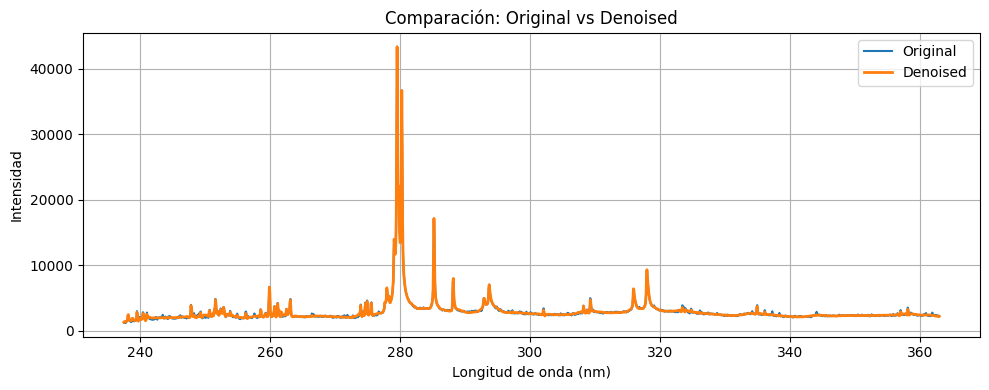

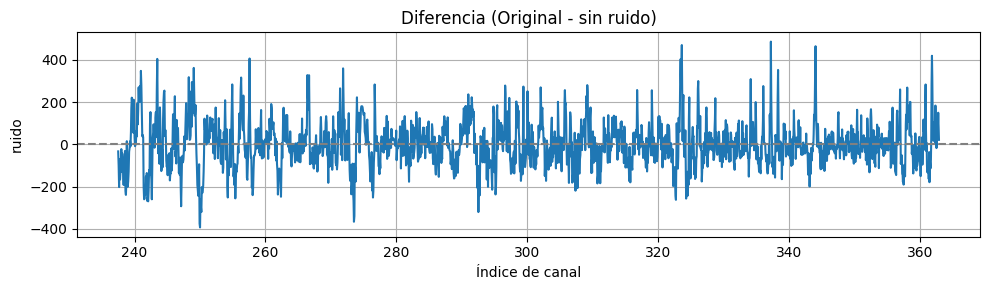

In [ ]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt

#Leer archivos
UV1 = "../spectra/2.E2E_olivine/Olivine_LIBS_shot01_7324767SP.txt" 
datos_UV1 = leer_archivo_txt(UV1)
espectro_UV1 = datos_UV1['Scope Corrected for Dark'].values
wavelength = datos_UV1['Wave'].values

#Le quitamos los extremos que no aportan nada
espectro_UV1 = espectro_UV1[16:-16]
wavelength = wavelength[16:-16]


# Aplicar denoising
denoised_spectrum_UV1 = denoise_spectrum_uwt(espectro_UV1)


# Comparamos resultados
plt.figure(figsize=(10, 4))
plt.plot(wavelength, espectro_UV1, label="Original")
plt.plot(wavelength, denoised_spectrum_UV1, label="Denoised", linewidth=2)
plt.title("Comparación: Original vs Denoised")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Ruido punto a punto
error = espectro_UV1 - denoised_spectrum_UV1
plt.figure(figsize=(10, 3))
plt.plot(wavelength, error, label='Ruido quitado')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Diferencia (Original - sin ruido)")
plt.xlabel("Índice de canal")
plt.ylabel("ruido")
plt.grid(True)
plt.tight_layout()
plt.show()